In [17]:
!git clone https://github.com/ChristosPaterakisntua/digit-recogniser-mnist.git

fatal: destination path 'digit-recogniser-mnist' already exists and is not an empty directory.


In [18]:
!git -C /content/digit-recogniser-mnist pull

Already up to date.


In [19]:
import os

print(os.listdir("/content/digit-recogniser-mnist"))

['predict.py', 'test.py', '__pycache__', 'utils.py', 'dataset.py', '.gitignore', '.git', 'evaluate.py', 'train.py', 'loader.py', 'model.py']


In [20]:
import sys

sys.path.insert(0, "/content/digit-recogniser-mnist")

In [33]:
from __future__ import annotations

from dataset import load_mnist
from model import CNNDigitRecogniserModel, MLPDigitRecogniserModel
from train import train, CHECKPOINT_PATH
from evaluate import load_trained_model, evaluate
from loader import load_raw_image
from predict import predict
from utils import select_device, ask_yes_or_no

In [31]:
device = select_device()
print(device)

train_model: bool = ask_yes_or_no("Train a new model?")
if train_model:
    train_cnn: bool = ask_yes_or_no("Train the cnn model?")
    train_mlp: bool = ask_yes_or_no("Train the mlp model?")

cuda


Epoch 22/50
Training loss: 0.12349814825853477
Checkpoint saved: saved_models/checkpoint.pt
Early stopping at epoch: 22


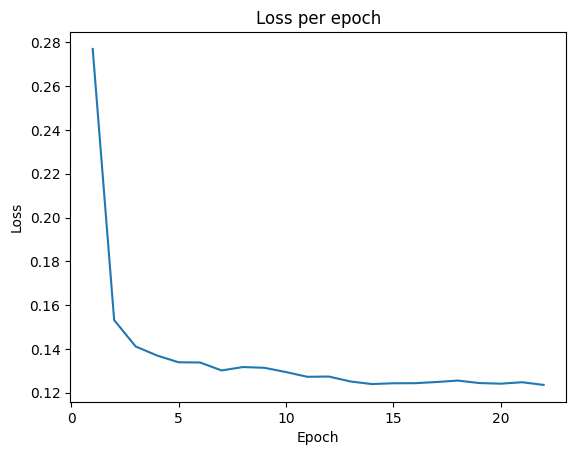

Final model saved: saved_models/model_CNN_1.pt


In [ ]:
if train_cnn:
    train_dataloader = load_mnist()
    model = CNNDigitRecogniserModel()
    train(
        model=model,
        data_loader=train_dataloader,
        device=device,
        model_id="CNN_1",
        checkpoint_path=CHECKPOINT_PATH,
    )

else:
    path = input("Path to trained model: ")
    model = load_trained_model(
        path=path,
        device=device,
    )

In [24]:
evaluation = evaluate(
    model=model,
    device=device,
)
print(f"Evaluation: {100 * evaluation:.2f}%")

Evaluation: 96.58%


Epoch 1/50
Training loss: 0.377881414491528
Checkpoint saved: saved_models/checkpoint.pt
Epoch 2/50
Training loss: 0.2866129800414395
Checkpoint saved: saved_models/checkpoint.pt
Epoch 3/50
Training loss: 0.27613423488265837
Checkpoint saved: saved_models/checkpoint.pt
Epoch 4/50
Training loss: 0.2728397174869897
Checkpoint saved: saved_models/checkpoint.pt
Epoch 5/50
Training loss: 0.2706439980765572
Checkpoint saved: saved_models/checkpoint.pt
Epoch 6/50
Training loss: 0.27130315735936167
Checkpoint saved: saved_models/checkpoint.pt
Epoch 7/50
Training loss: 0.2702470910367168
Checkpoint saved: saved_models/checkpoint.pt
Epoch 8/50
Training loss: 0.2697410562068884
Checkpoint saved: saved_models/checkpoint.pt
Epoch 9/50
Training loss: 0.2676693604203465
Checkpoint saved: saved_models/checkpoint.pt
Epoch 10/50
Training loss: 0.2682276183801587
Checkpoint saved: saved_models/checkpoint.pt
Epoch 11/50
Training loss: 0.2680978704184915
Checkpoint saved: saved_models/checkpoint.pt
Epoch 1

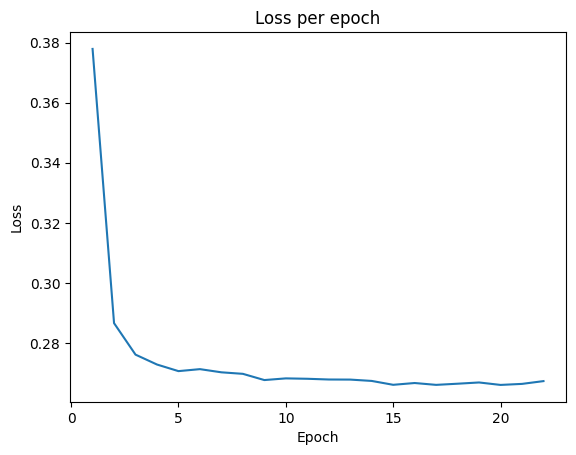

Final model saved: saved_models/model_MLP_1.pt


In [34]:
if train_mlp:
    train_dataloader = load_mnist()
    model1 = MLPDigitRecogniserModel()
    train(
        model=model1,
        data_loader=train_dataloader,
        device=device,
        model_id="MLP_1",
        checkpoint_path=CHECKPOINT_PATH,
    )

else:
    path = input("Path to trained model: ")
    model1 = load_trained_model(
        path=path,
        device=device,
    )

In [35]:
evaluation = evaluate(
    model=model1,
    device=device,
)
print(f"Evaluation: {100 * evaluation:.2f}%")

Evaluation: 92.20%


In [ ]:
do_prediction: bool = ask_yes_or_no("Want a prediction?")

if do_prediction:
    print("Type exit to stop")
    while True:
        path = input("Path: ").strip()
        if path.lower() == "exit":
            break
        img_tensor = load_raw_image(path)
        prediction = predict(
            model=(model if model is not None else model1),
            image_tensor=img_tensor,
            device=device,
        )
        print(f"Model predicted: {prediction}")